### Prompt Chaining

##### Input -> LLM -> LLM -> Output 
##### (If a sequential workflow has more than 1 LLM nodes then its prompt chaining)

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_cohere import ChatCohere
from dotenv import load_dotenv
load_dotenv()

d:\Code\Python\AI\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

#### Define Model

In [2]:
model = ChatCohere(model="command-a-03-2025")

#### Define State

In [3]:
class BlogStates(TypedDict):
    topic: str
    outline: str
    blog: str

#### Define Node Function

In [4]:
def create_outline(state: BlogStates) -> BlogStates:
    topic = state["topic"]
    prompt = f"Create a detailed outline for a blog post about {topic}."
    response = model.invoke(prompt)
    state["outline"] = response.content
    return state

In [5]:
def create_blog(state: BlogStates) -> BlogStates:
    outline = state["outline"]
    prompt = f"Write a blog post based on the following outline:\n{outline}"
    response = model.invoke(prompt)
    state["blog"] = response.content
    return state

#### Create Graph

In [6]:
graph = StateGraph(BlogStates)

### Add Nodes to the graph

In [7]:
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

#### Add Edges to the graph

In [8]:
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

#### Compile  graph

In [9]:
workflow = graph.compile()

#### Show Graph

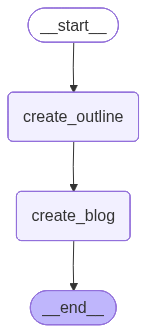

In [10]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

#### Execute Graph

In [11]:
input_state = {
    'topic': "Kolkata"
}

output_state = workflow.invoke(input_state)

#### Final State

In [12]:
print(output_state)

{'topic': 'Kolkata', 'outline': '**Blog Post Outline: Exploring the Heart of Kolkata – A City of Culture, History, and Charm**\n\n**I. Introduction**  \n   - **Hook:** "Where the past whispers through colonial architecture, the present dances to the rhythm of Durga Puja, and the future simmers in a cup of chai – welcome to Kolkata, the cultural capital of India."  \n   - **Overview:** Kolkata, formerly Calcutta, is a city that seamlessly blends tradition and modernity. This blog post will take you on a journey through its rich history, vibrant culture, culinary delights, and hidden gems.  \n   - **Thesis Statement:** From its literary legacy to its bustling streets, Kolkata is a city that captivates the soul and leaves an indelible mark on every visitor.\n\n**II. A Glimpse into Kolkata’s History**  \n   - **Colonial Roots:**  \n     - Founded as an East India Company trading post in 1690.  \n     - The legacy of British rule reflected in iconic landmarks like Victoria Memorial and Howr

In [13]:
print("Outline:\n", output_state['outline'])
print("\nBlog:\n", output_state['blog'])

Outline:
 **Blog Post Outline: Exploring the Heart of Kolkata – A City of Culture, History, and Charm**

**I. Introduction**  
   - **Hook:** "Where the past whispers through colonial architecture, the present dances to the rhythm of Durga Puja, and the future simmers in a cup of chai – welcome to Kolkata, the cultural capital of India."  
   - **Overview:** Kolkata, formerly Calcutta, is a city that seamlessly blends tradition and modernity. This blog post will take you on a journey through its rich history, vibrant culture, culinary delights, and hidden gems.  
   - **Thesis Statement:** From its literary legacy to its bustling streets, Kolkata is a city that captivates the soul and leaves an indelible mark on every visitor.

**II. A Glimpse into Kolkata’s History**  
   - **Colonial Roots:**  
     - Founded as an East India Company trading post in 1690.  
     - The legacy of British rule reflected in iconic landmarks like Victoria Memorial and Howrah Bridge.  
   - **Role in India